In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import folium


# Data Import

In [6]:
gdf_Aglanta = gpd.read_file("InvestAtlanta_export/Aglanta_FFA_2025_ATL_Only.shp")
gdf_Aglanta = gdf_Aglanta.to_crs(epsg=3857)

gdf_lila = gpd.read_file("InvestAtlanta_export/lila_halfmi_census.shp")
gdf_lila = gdf_lila.to_crs(epsg=3857)


gdf_Tax = gpd.read_file("InvestAtlanta_export/Tax_Parcels_2025.shp")
gdf_Tax = gdf_Tax.to_crs(epsg=3857)


gdf_Tax = gdf_Tax.to_crs(epsg=3857)

In [9]:

gdf_Tax["LIVUNITS"] = pd.to_numeric(gdf_Tax["LIVUNITS"], errors="coerce")

# filter: LIVUNITS > 0
gdf_Tax = gdf_Tax[
    (gdf_Tax["LIVUNITS"] > 0) &
    (gdf_Tax["LIVUNITS"].notna())
].copy()

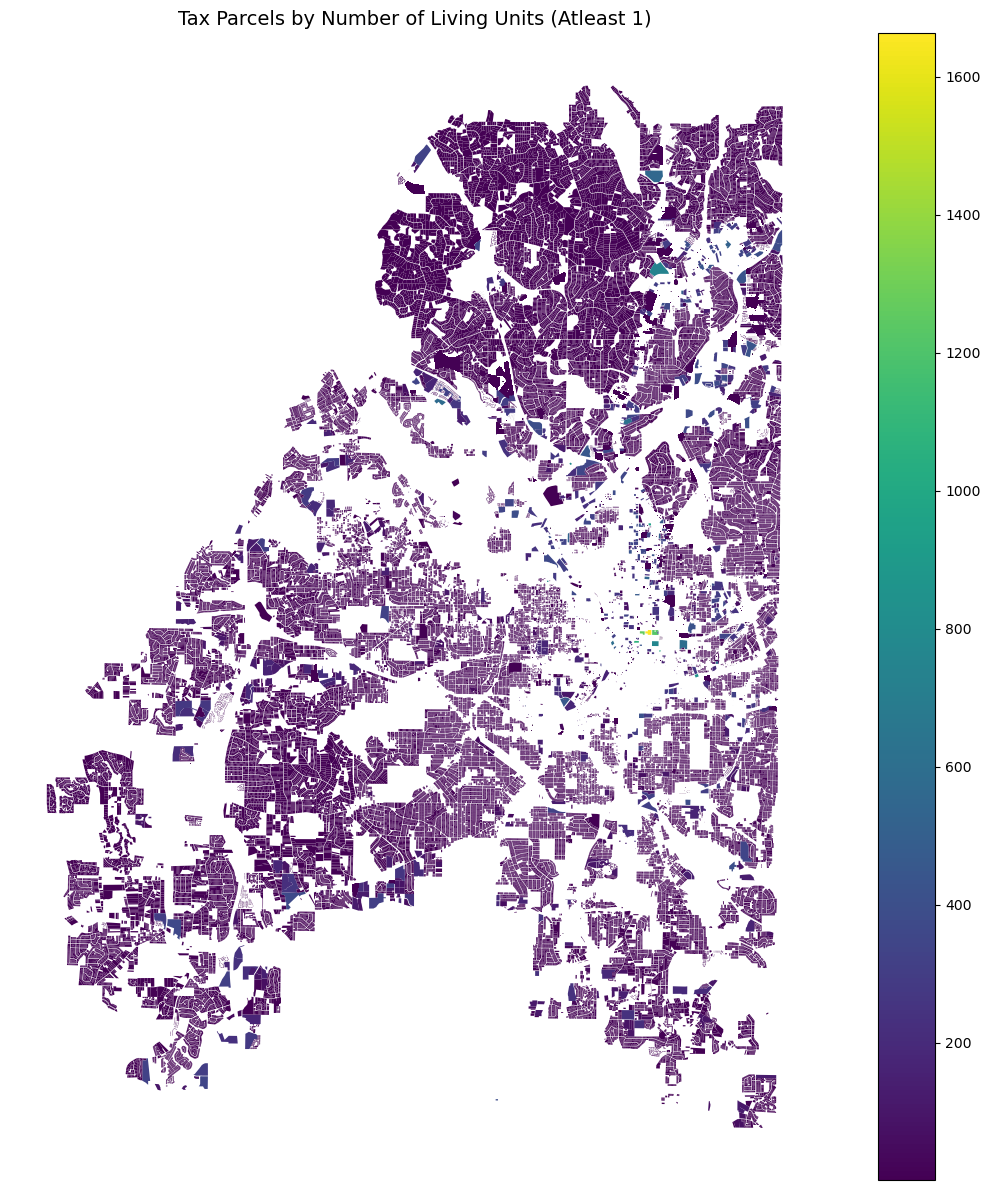

In [11]:
fig, ax = plt.subplots(figsize=(12, 12))

gdf_Tax.plot(
    column="LIVUNITS",
    ax=ax,
    legend=True,
    cmap="viridis",
    linewidth=0.1,
    edgecolor="none"
)

ax.set_title("Tax Parcels by Number of Living Units (>1)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [13]:
gdf_Tax

,OBJECTID,LOWPARCELI,PARCELID,BUILDING,UNIT,CVTTXCD,CVTTXDSCRP,CLASSCD,CLASSDSCRP,LIVUNITS,...,COUNCIL,NPU,NEIGHBORHO,ADDRNUM,ADDRSTREET,ADDRSUFFIX,ADDRPOSDIR,SHAPE_Area,SHAPE_Leng,geometry
14131,14132,17 00090001054,17 000900010541,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,3542,KINGSBORO,RD,NE,15410.935673,579.129308,"POLYGON ((-9390244.184 4008838.553, -9390269.9..."
14132,14133,17 00090001075,17 000900010756,#,7,05,None,R3,None,1.0,...,7,B,Ridgedale Park,3533,ROXBORO,RD,NE,1343.911541,157.003657,"POLYGON ((-9390482.762 4008835.19, -9390492.21..."
14133,14134,17 00090001068,17 000900010681,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,987,EULALIA,RD,NE,19103.770553,614.841990,"POLYGON ((-9390354.188 4008920.673, -9390385.8..."
14134,14135,17 00100008015,17 001000080152,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,3627,KINGSBORO,RD,NE,22797.417784,721.541720,"POLYGON ((-9389763.886 4009125.243, -9389833.7..."
14135,14136,17 00090001020,17 000900010202,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,1044,EULALIA,RD,NE,18240.379683,582.265904,"POLYGON ((-9390178.207 4009021.963, -9390178.7..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171001,171002,14 01190005142,14 011900051424,UNIT,305,05T,None,R3,None,1.0,...,4,S,Oakland City,1095,TUCKER,AVE,SW,99.999600,39.999920,"POLYGON ((-9397984.192 3991904.363, -9397984.2..."
171002,171003,14 01190005143,14 011900051432,UNIT,306,05T,None,R3,None,1.0,...,4,S,Oakland City,1095,TUCKER,AVE,SW,99.999600,39.999920,"POLYGON ((-9397979.573 3991900.064, -9397979.5..."
171026,171027,17 0108 LL224,17 0108 LL2242,UNIT,3108,05X,None,R3,None,1.0,...,3,E,Atlantic Station,270,SEVENTEENTH,ST,NW,99.999600,39.999920,"POLYGON ((-9395116.916 4000750.862, -9395116.9..."
171027,171028,17 0108 LL225,17 0108 LL2259,UNIT,3906,05X,None,R3,None,1.0,...,3,E,Atlantic Station,270,SEVENTEENTH,ST,NW,99.999600,39.999920,"POLYGON ((-9395116.916 4000750.862, -9395116.9..."


In [24]:
df_License = pd.read_excel("InvestAtlanta_export/License_Records_2025.xlsx")

In [20]:
df_License["naics_name"].unique()

array(['Interior Design Services', 'Media Representatives',
       'Tobacco Stores ', 'Beauty Salons ', 'Full-Service Restaurants ',
       'Drycleaning and Laundry Services (except Coin-Operated) ',
       'Barber Shops ', 'All Other Specialty Food Stores ',
       'Offices of Mental Health Practitioners (except Physicians) ',
       'Other Activities Related to Real Estate ',
       'Clothing Accessories Stores ', 'Jewelry Stores ',
       'Lessors of Residential Buildings and Dwellings ',
       'Convenience Stores ', 'Convention and Trade Show Organizers',
       'Nail Salons ', 'Marketing Consulting Services ',
       'Investment Advice ', 'Pet and Pet Supplies Stores ',
       'Used Car Dealers ', 'New Housing For-Sale Builders ',
       'Limited-Service Restaurants ',
       'Offices of Physicians (except Mental Health Specialists) ',
       'Commercial and Institutional Building Construction ',
       'Educational Support Services',
       'Hotels (except Casino Hotels) and Mot

In [26]:
print(gdf_lila["within_half_mile"].dtype)

bool


In [17]:
list(enumerate(gdf_lila.columns))

[(0, 'CnssTrc'),
 (1, 'State'),
 (2, 'County'),
 (3, 'LILAT_1A1'),
 (4, 'LILAT_A'),
 (5, 'LILAT_1A2'),
 (6, 'LILAT_V'),
 (7, 'PvrtyRt'),
 (8, 'MdnFmlI'),
 (9, 'LAhlf10'),
 (10, 'LATrct_'),
 (11, 'TrcSNAP'),
 (12, 'tract'),
 (13, 'STATEFP'),
 (14, 'COUNTYF'),
 (15, 'TRACTCE'),
 (16, 'BLOCKCE'),
 (17, 'BLOCKID'),
 (18, 'PARTFLG'),
 (19, 'HOUSING'),
 (20, 'POP10'),
 (21, 'geometry')]

# Live Unit

In [4]:
gdf_Tax["LIVUNITS"] = pd.to_numeric(gdf_Tax["LIVUNITS"], errors="coerce")

gdf_Tax = gdf_Tax[
    (gdf_Tax["LIVUNITS"] >= 1) &
    (gdf_Tax["LIVUNITS"].notna())
]

In [5]:
gdf_Tax

,OBJECTID,LOWPARCELI,PARCELID,BUILDING,UNIT,CVTTXCD,CVTTXDSCRP,CLASSCD,CLASSDSCRP,LIVUNITS,...,COUNCIL,NPU,NEIGHBORHO,ADDRNUM,ADDRSTREET,ADDRSUFFIX,ADDRPOSDIR,SHAPE_Area,SHAPE_Leng,geometry
14131,14132,17 00090001054,17 000900010541,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,3542,KINGSBORO,RD,NE,15410.935673,579.129308,"POLYGON ((-9390244.184 4008838.553, -9390269.9..."
14132,14133,17 00090001075,17 000900010756,#,7,05,None,R3,None,1.0,...,7,B,Ridgedale Park,3533,ROXBORO,RD,NE,1343.911541,157.003657,"POLYGON ((-9390482.762 4008835.19, -9390492.21..."
14133,14134,17 00090001068,17 000900010681,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,987,EULALIA,RD,NE,19103.770553,614.841990,"POLYGON ((-9390354.188 4008920.673, -9390385.8..."
14134,14135,17 00100008015,17 001000080152,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,3627,KINGSBORO,RD,NE,22797.417784,721.541720,"POLYGON ((-9389763.886 4009125.243, -9389833.7..."
14135,14136,17 00090001020,17 000900010202,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,1044,EULALIA,RD,NE,18240.379683,582.265904,"POLYGON ((-9390178.207 4009021.963, -9390178.7..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171001,171002,14 01190005142,14 011900051424,UNIT,305,05T,None,R3,None,1.0,...,4,S,Oakland City,1095,TUCKER,AVE,SW,99.999600,39.999920,"POLYGON ((-9397984.192 3991904.363, -9397984.2..."
171002,171003,14 01190005143,14 011900051432,UNIT,306,05T,None,R3,None,1.0,...,4,S,Oakland City,1095,TUCKER,AVE,SW,99.999600,39.999920,"POLYGON ((-9397979.573 3991900.064, -9397979.5..."
171026,171027,17 0108 LL224,17 0108 LL2242,UNIT,3108,05X,None,R3,None,1.0,...,3,E,Atlantic Station,270,SEVENTEENTH,ST,NW,99.999600,39.999920,"POLYGON ((-9395116.916 4000750.862, -9395116.9..."
171027,171028,17 0108 LL225,17 0108 LL2259,UNIT,3906,05X,None,R3,None,1.0,...,3,E,Atlantic Station,270,SEVENTEENTH,ST,NW,99.999600,39.999920,"POLYGON ((-9395116.916 4000750.862, -9395116.9..."


# Liscence

In [33]:
df_License

,license_number,company_name,company_dba,license_classification,issued_date,naics_code,naics_name,predirection,address_line1,address_line2,...,city,state,postal_code,address_concat,address_api,longitude,latitude,disinvested_neighborhood,council_district,npu
0,GBL-0121-00257,H & H Interiors LLC,NaN,Other Services except Public Administration,2025-01-07 13:21:16.143,541410.0,Interior Design Services,NE,2652 Forrest,NaN,...,Atlanta,GA,NaN,2652 Forrest nan WAY Atlanta GA nan,"2652 Forrest Way NE, Atlanta, Georgia, 30305",-84.379893,33.827640,False,7,B
1,GBL-0121-00258,One Lion Studios LLC,NaN,Other Services except Public Administration,2025-02-16 18:39:21.153,541840.0,Media Representatives,NaN,3343 Peachtree Rd NE,NaN,...,Atlanta,GA,30326,3343 Peachtree Rd NE nan nan Atlanta GA 30326,"3343 Peachtree Rd NE, Atlanta, Georgia, 30326",-84.367109,33.846760,False,7,B
2,GBL-0121-00272,Destingkt Designs LLC,NaN,Other Services except Public Administration,2025-03-04 23:04:53.980,541410.0,Interior Design Services,NaN,931,PONCE DE LEON,...,Atlanta,GA,NaN,931 PONCE DE LEON AVE Atlanta GA nan,"931 Ponce de Leon Ave NE, Atlanta, Georgia, 30306",-84.356939,33.773524,False,2,N
3,GBL-0121-00274,Mac Cigars LLC,J's Cigars,Retail Trade,2025-02-25 23:09:11.497,453991.0,Tobacco Stores,NaN,2072,Defoors Ferry,...,Atlanta,GA,30318,2072 Defoors Ferry RD Atlanta GA 30318,"2072 Defoors Ferry Rd NW, Atlanta, Georgia, 30318",-84.426318,33.812071,False,9,D
4,GBL-0121-00283,Essence of She Day Spa Salon,NaN,Other Services except Public Administration,2025-01-09 19:04:30.857,812112.0,Beauty Salons,NaN,144,MORELAND,...,ATLANTA,GA,30307,144 MORELAND AVE ATLANTA GA 30307,"144 Moreland Ave NE, Atlanta, Georgia, 30307",-84.349501,33.756604,False,5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17618,LGB-190652-2020,CAST & CREW PRODUCTION SER LLC,NaN,Manufacturing,2025-03-20 01:03:58.763,512110.0,Motion Picture and Video Production,NaN,1349,W PEACHTREE,...,ATLANTA,GA,30309,1349 W PEACHTREE ST ATLANTA GA 30309,"1349 W Peachtree St NW, Atlanta, Georgia, 30309",-84.387308,33.791687,False,District 6,E
17619,LGB-190653-2020,LISADAESTYLED LLC,NaN,Other Services except Public Administration,2025-03-31 01:02:47.710,561439.0,Other Business Service Centers (including Copy...,NaN,40,PEACHTREE VALLEY,...,ATLANTA,GA,30309,40 PEACHTREE VALLEY RD ATLANTA GA 30309,"40 Peachtree Valley Rd NE, Atlanta, Georgia, 3...",-84.389721,33.811184,False,District 6,E
17620,LGB-190665-2020,"B-T-L PAYROLLS, LLC",NaN,Manufacturing,2025-03-20 01:03:40.333,512110.0,Motion Picture and Video Production,NaN,1349,W PEACHTREE,...,ATLANTA,GA,30309,1349 W PEACHTREE ST ATLANTA GA 30309,"1349 W Peachtree St NW, Atlanta, Georgia, 30309",-84.387308,33.791687,False,District 6,E
17621,LGB-190667-2020,"NEW PAYROLL ASSOCIATES, LLC",NaN,Manufacturing,2025-03-20 01:02:54.400,512110.0,Motion Picture and Video Production,NaN,1349,W PEACHTREE,...,ATLANTA,GA,30309,1349 W PEACHTREE ST ATLANTA GA 30309,"1349 W Peachtree St NW, Atlanta, Georgia, 30309",-84.387308,33.791687,False,District 6,E


In [ ]:
df_License = pd.read_excel("InvestAtlanta_export/License_Records_2025.xlsx")

grocery_categories = [
    "Supermarkets and Other Grocery (except Convenience) Stores ",
    "Fruit and Vegetable Markets ",
    "Meat Markets ",
    "Fish and Seafood Markets ",
]


df_grocery = (
    df_License
    .loc[df_License["naics_name"].isin(grocery_categories)]
    .loc[lambda df: df["address_api"].str.contains("Atlanta, Georgia", na=False)]
    .copy()
)

df_grocery



,license_number,company_name,company_dba,license_classification,issued_date,naics_code,naics_name,predirection,address_line1,address_line2,...,city,state,postal_code,address_concat,address_api,longitude,latitude,disinvested_neighborhood,council_district,npu
612,GBL-0222-09794,"Simply Organic Market, Inc.",NaN,Retail Trade,2025-02-13 16:03:58.000,445110.0,Supermarkets and Other Grocery (except Conveni...,NaN,759 Dill Avenue,NaN,...,Atlanta,GA,30310,759 Dill Avenue nan nan Atlanta GA 30310,"759 Dill Ave SW, Atlanta, Georgia, 30310",-84.412667,33.718433,True,12,X
694,GBL-0222-10205,Pittsburgh Community Market,NaN,"Arts, Entertainment & Recreation",2025-02-15 19:07:21.830,445110.0,Supermarkets and Other Grocery (except Conveni...,NaN,352 University Avenue Sw Atlanta Ga 30310,NaN,...,NaN,NaN,NaN,352 University Avenue Sw Atlanta Ga 30310 nan ...,"352 University Ave SW, Atlanta, Georgia, 30310",-84.399772,33.721187,True,12,V
1223,GBL-0322-10990,12 Hours LLC,NaN,Retail Trade,2025-02-17 23:04:24.210,445110.0,Supermarkets and Other Grocery (except Conveni...,NaN,387 Cleveland Ave Sw,STE 2,...,Atlanta,GA,30315,387 Cleveland Ave Sw STE 2 nan Atlanta GA 30315,"387 Cleveland Ave SW, Suite 2, Atlanta, Georgi...",-84.402154,33.681607,True,12,X
1417,GBL-0323-19981,"Publix Super Markets, Inc.","Publix Super Markets, Inc. #1825",Retail Trade,2025-01-16 17:18:38.263,445110.0,Supermarkets and Other Grocery (except Conveni...,NaN,572 Hank Aaron,NaN,...,Atlanta,GA,303122896,572 Hank Aaron nan DR Atlanta GA 303122896,"572 Hank Aaron Dr SE, Atlanta, Georgia, 30312",-84.387062,33.738851,False,1,V
1729,GBL-0422-12172,MAULIA INC,QUICKPICK FOODMART,Retail Trade,2025-02-13 09:12:26.570,445110.0,Supermarkets and Other Grocery (except Conveni...,NaN,1634,LAKEWOOD,...,Atlanta,GA,NaN,1634 LAKEWOOD Avenue Atlanta GA nan,"1634 Lakewood Ave SE, Atlanta, Georgia, 30315",-84.379616,33.709644,True,1,Y
1776,GBL-0422-12617,Frazie's Meat & Market,NaN,Retail Trade,2025-01-22 15:04:24.643,445210.0,Meat Markets,NaN,2030,Main,...,Atlanta,GA,30318,2030 Main ST Atlanta GA 30318,"2030 Main St NW, Atlanta, Georgia, 30318",-84.471881,33.811154,False,9,D
1929,GBL-0424-30054,Lee Street Meats LLC,NaN,Accommodation and Food Services,2025-02-14 13:05:54.940,445110.0,Supermarkets and Other Grocery (except Conveni...,NaN,1265,LEE,...,Atlanta,GA,30310,1265 LEE Street Atlanta GA 30310,"1265 Lee St SW, Atlanta, Georgia, 30310",-84.424565,33.720616,True,4,S
2215,GBL-0522-13828,"HANK AARON GROCERY, LLC",HANK AARON GROCERY,Retail Trade,2025-02-04 10:06:47.547,445110.0,Supermarkets and Other Grocery (except Conveni...,SE,834 HANK AARON DRIVE,NaN,...,ATLANTA,GA,30315,834 HANK AARON DRIVE nan nan ATLANTA GA 30315,"834 Hank Aaron Dr SE, Atlanta, Georgia, 30315",-84.387655,33.732039,False,1,V
2627,GBL-0622-14209,NEIGHBORHOOD 2070 INC,NEIGHBORHOOD GROCERY,Retail Trade,2025-01-29 09:35:37.353,445110.0,Supermarkets and Other Grocery (except Conveni...,NaN,2070 ALISON CT SW,NaN,...,ATLANTA,GA,30311,2070 ALISON CT SW nan nan ATLANTA GA 30311,"2070 Alison Ct SW, Atlanta, Georgia, 30311",-84.456472,33.700385,True,11,R
2656,GBL-0622-14433,Yunny LLC,City Produce,Other Services except Public Administration,2025-01-25 15:06:20.940,445230.0,Fruit and Vegetable Markets,NaN,209,EDGEWOOD,...,Atlanta,GA,NaN,209 EDGEWOOD Avenue Atlanta GA nan,"209 Edgewood Ave SE, Atlanta, Georgia, 30303",-84.379880,33.754047,False,5,M


In [29]:
df_License
df_License["license_classification"].unique()

df_License_food = (
    df_License
    .loc[df_License["license_classification"] == "Retail Trade"]
    .loc[lambda df: df["address_api"].str.contains("Atlanta, Georgia", na=False)]
    .copy()
)

df_License_food

,license_number,company_name,company_dba,license_classification,issued_date,naics_code,naics_name,predirection,address_line1,address_line2,...,city,state,postal_code,address_concat,address_api,longitude,latitude,disinvested_neighborhood,council_district,npu
3,GBL-0121-00274,Mac Cigars LLC,J's Cigars,Retail Trade,2025-02-25 23:09:11.497,453991.0,Tobacco Stores,NaN,2072,Defoors Ferry,...,Atlanta,GA,30318,2072 Defoors Ferry RD Atlanta GA 30318,"2072 Defoors Ferry Rd NW, Atlanta, Georgia, 30318",-84.426318,33.812071,False,9,D
9,GBL-0121-01137,Sean's Candler Park,NaN,Retail Trade,2025-02-16 18:41:03.713,445299.0,All Other Specialty Food Stores,NaN,1394,MCLENDON,...,Atlanta,GA,NaN,1394 MCLENDON AVE Atlanta GA nan,"1394 McLendon Ave NE, Atlanta, Georgia, 30307",-84.341868,33.765009,False,2,N
10,GBL-0121-01137,Sean's Candler Park,NaN,Retail Trade,2025-02-16 18:41:03.713,445299.0,All Other Specialty Food Stores,NaN,1394,MCLENDON,...,Atlanta,GA,NaN,1394 MCLENDON AVE Atlanta GA nan,"1394 McLendon Ave NE, Atlanta, Georgia, 30307",-84.341868,33.765009,False,2,N
16,GBL-0121-01163,Afrik Brands,NaN,Retail Trade,2025-02-24 23:08:32.743,448150.0,Clothing Accessories Stores,NaN,285,CENTENNIAL OLYMPIC PARK,...,Atlanta,GA,NaN,285 CENTENNIAL OLYMPIC PARK DR Atlanta GA nan,"285 Centennial Olympic Park Dr NW, Atlanta, Ge...",-84.391656,33.762576,False,4,M
17,GBL-0121-01164,Big Apple Jewelry,Luxor Fine Jewelry,Retail Trade,2025-02-19 23:08:00.310,448310.0,Jewelry Stores,NaN,4279,Roswell,...,Atlanta,GA,30342,4279 Roswell RD Atlanta GA 30342,"4279 Roswell Rd NE, Atlanta, Georgia, 30342",-84.379331,33.871124,False,7,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17548,LGB-189247-2020,SALMA ABEDIN 2019 LLC,NaN,Retail Trade,2025-05-21 15:55:18.000,424410.0,General Line Grocery Merchant Wholesalers,NaN,2200,CAMPBELLTON,...,ATLANTA,GA,30311,2200 CAMPBELLTON RD ATLANTA GA 30311,"2200 Campbellton Rd SW, Atlanta, Georgia, 30311",-84.460650,33.704998,True,District 11,R
17566,LGB-189653-2020,GLOSSIER INC,NaN,Retail Trade,2025-05-07 14:51:45.000,453998.0,All Other Miscellaneous Store Retailers (excep...,NaN,675,PONCE DE LEON,...,ATLANTA,GA,30308,675 PONCE DE LEON AVE ATLANTA GA 30308,"675 Ponce de Leon Ave NE, Atlanta, Georgia, 30308",-84.365750,33.773003,False,District 2,M
17573,LGB-189726-2020,SEVYN FIT LLC,NaN,Retail Trade,2025-04-02 21:04:58.473,448140.0,Family Clothing Stores,NaN,400,W PEACHTREE,...,ATLANTA,GA,30308,400 W PEACHTREE ST ATLANTA GA 30308,"400 W Peachtree St NW, Atlanta, Georgia, 30308",-84.388389,33.765671,False,District 2,M
17579,LGB-189949-2020,LOS LLC,NaN,Retail Trade,2025-04-23 21:02:12.830,448140.0,Family Clothing Stores,NaN,230,CLEVELAND,...,ATLANTA,GA,30315,230 CLEVELAND AVE ATLANTA GA 30315,"230 Cleveland Ave SW, Atlanta, Georgia, 30315",-84.395595,33.679495,True,District 12,Z


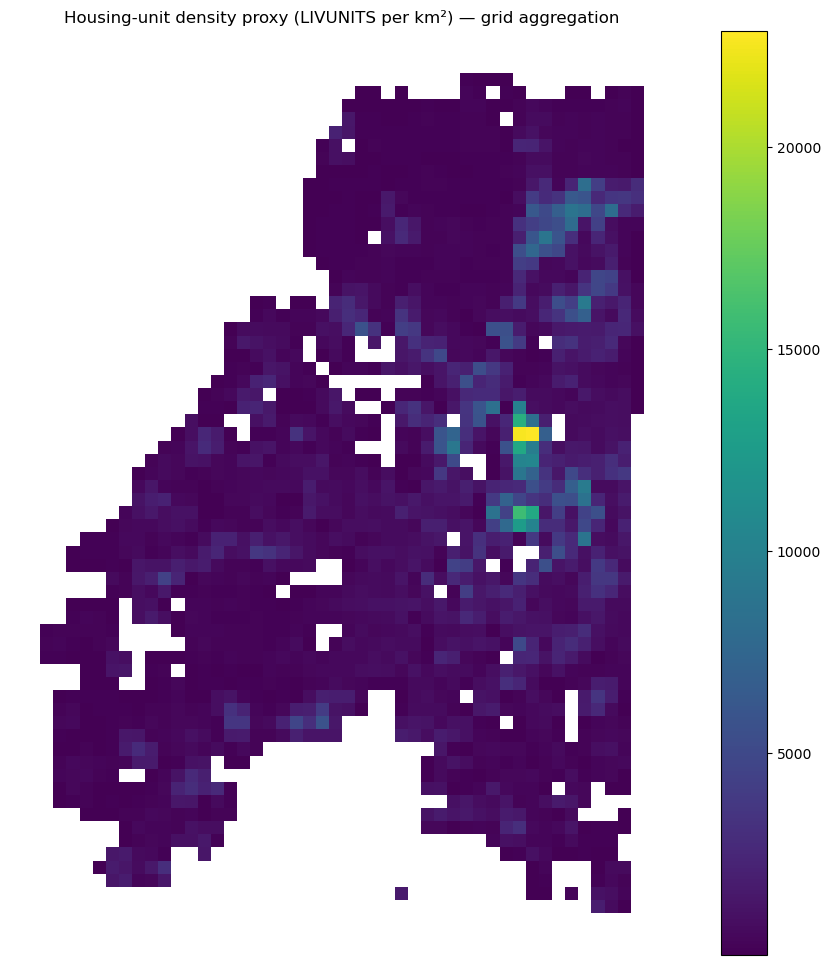

In [10]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# numeric + filter (your code)
gdf_Tax["LIVUNITS"] = pd.to_numeric(gdf_Tax["LIVUNITS"], errors="coerce")
gdf_Tax = gdf_Tax[(gdf_Tax["LIVUNITS"] >= 1) & (gdf_Tax["LIVUNITS"].notna())].copy()

# use a metric CRS for density (Atlanta area: EPSG:2240 is GA West ft; 3857 is ok-ish but not ideal)
gdf_Tax = gdf_Tax.to_crs(epsg=3857)

from shapely.geometry import box

cell_size = 500  # meters

minx, miny, maxx, maxy = gdf_Tax.total_bounds

# grid coordinates
xs = np.arange(minx, maxx + cell_size, cell_size)
ys = np.arange(miny, maxy + cell_size, cell_size)

# create fishnet
grid = gpd.GeoDataFrame(
    {"geometry": [box(x, y, x + cell_size, y + cell_size) for x in xs[:-1] for y in ys[:-1]]},
    crs=gdf_Tax.crs
)

# spatial join parcels -> grid cells
join = gpd.sjoin(
    gdf_Tax[["LIVUNITS", "geometry"]],
    grid.reset_index().rename(columns={"index": "grid_id"}),
    how="inner",
    predicate="intersects"
)

# sum units per cell
cell_units = join.groupby("grid_id")["LIVUNITS"].sum()

grid["LIVUNITS_sum"] = grid.index.map(cell_units).fillna(0)

# density units per km^2
cell_area_km2 = (cell_size * cell_size) / 1e6
grid["units_per_km2"] = grid["LIVUNITS_sum"] / cell_area_km2

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# plot only cells with >0 units to reduce clutter
grid[grid["LIVUNITS_sum"] > 0].plot(
    ax=ax,
    column="units_per_km2",
    legend=True,
    linewidth=0,
)

ax.set_axis_off()
ax.set_title("Housing-unit density proxy (LIVUNITS per km²) — grid aggregation")
plt.show()

In [30]:
df_License

,license_number,company_name,company_dba,license_classification,issued_date,naics_code,naics_name,predirection,address_line1,address_line2,...,city,state,postal_code,address_concat,address_api,longitude,latitude,disinvested_neighborhood,council_district,npu
0,GBL-0121-00257,H & H Interiors LLC,NaN,Other Services except Public Administration,2025-01-07 13:21:16.143,541410.0,Interior Design Services,NE,2652 Forrest,NaN,...,Atlanta,GA,NaN,2652 Forrest nan WAY Atlanta GA nan,"2652 Forrest Way NE, Atlanta, Georgia, 30305",-84.379893,33.827640,False,7,B
1,GBL-0121-00258,One Lion Studios LLC,NaN,Other Services except Public Administration,2025-02-16 18:39:21.153,541840.0,Media Representatives,NaN,3343 Peachtree Rd NE,NaN,...,Atlanta,GA,30326,3343 Peachtree Rd NE nan nan Atlanta GA 30326,"3343 Peachtree Rd NE, Atlanta, Georgia, 30326",-84.367109,33.846760,False,7,B
2,GBL-0121-00272,Destingkt Designs LLC,NaN,Other Services except Public Administration,2025-03-04 23:04:53.980,541410.0,Interior Design Services,NaN,931,PONCE DE LEON,...,Atlanta,GA,NaN,931 PONCE DE LEON AVE Atlanta GA nan,"931 Ponce de Leon Ave NE, Atlanta, Georgia, 30306",-84.356939,33.773524,False,2,N
3,GBL-0121-00274,Mac Cigars LLC,J's Cigars,Retail Trade,2025-02-25 23:09:11.497,453991.0,Tobacco Stores,NaN,2072,Defoors Ferry,...,Atlanta,GA,30318,2072 Defoors Ferry RD Atlanta GA 30318,"2072 Defoors Ferry Rd NW, Atlanta, Georgia, 30318",-84.426318,33.812071,False,9,D
4,GBL-0121-00283,Essence of She Day Spa Salon,NaN,Other Services except Public Administration,2025-01-09 19:04:30.857,812112.0,Beauty Salons,NaN,144,MORELAND,...,ATLANTA,GA,30307,144 MORELAND AVE ATLANTA GA 30307,"144 Moreland Ave NE, Atlanta, Georgia, 30307",-84.349501,33.756604,False,5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17618,LGB-190652-2020,CAST & CREW PRODUCTION SER LLC,NaN,Manufacturing,2025-03-20 01:03:58.763,512110.0,Motion Picture and Video Production,NaN,1349,W PEACHTREE,...,ATLANTA,GA,30309,1349 W PEACHTREE ST ATLANTA GA 30309,"1349 W Peachtree St NW, Atlanta, Georgia, 30309",-84.387308,33.791687,False,District 6,E
17619,LGB-190653-2020,LISADAESTYLED LLC,NaN,Other Services except Public Administration,2025-03-31 01:02:47.710,561439.0,Other Business Service Centers (including Copy...,NaN,40,PEACHTREE VALLEY,...,ATLANTA,GA,30309,40 PEACHTREE VALLEY RD ATLANTA GA 30309,"40 Peachtree Valley Rd NE, Atlanta, Georgia, 3...",-84.389721,33.811184,False,District 6,E
17620,LGB-190665-2020,"B-T-L PAYROLLS, LLC",NaN,Manufacturing,2025-03-20 01:03:40.333,512110.0,Motion Picture and Video Production,NaN,1349,W PEACHTREE,...,ATLANTA,GA,30309,1349 W PEACHTREE ST ATLANTA GA 30309,"1349 W Peachtree St NW, Atlanta, Georgia, 30309",-84.387308,33.791687,False,District 6,E
17621,LGB-190667-2020,"NEW PAYROLL ASSOCIATES, LLC",NaN,Manufacturing,2025-03-20 01:02:54.400,512110.0,Motion Picture and Video Production,NaN,1349,W PEACHTREE,...,ATLANTA,GA,30309,1349 W PEACHTREE ST ATLANTA GA 30309,"1349 W Peachtree St NW, Atlanta, Georgia, 30309",-84.387308,33.791687,False,District 6,E


/var/folders/4j/d42x79c52dq9lr5g5d4w7vnc0000gn/T/ipykernel_85431/1516409135.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffer_union = gdf_Aglanta.buffer(half_mile_m).unary_union
/opt/anaconda3/envs/qtm151/lib/python3.12/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)
/opt/anaconda3/envs/qtm151/lib/python3.12/site-packages/shapely/predicates.py:1034: RuntimeWarning: invalid value encountered in within
  return lib.within(a, b, **kwargs)


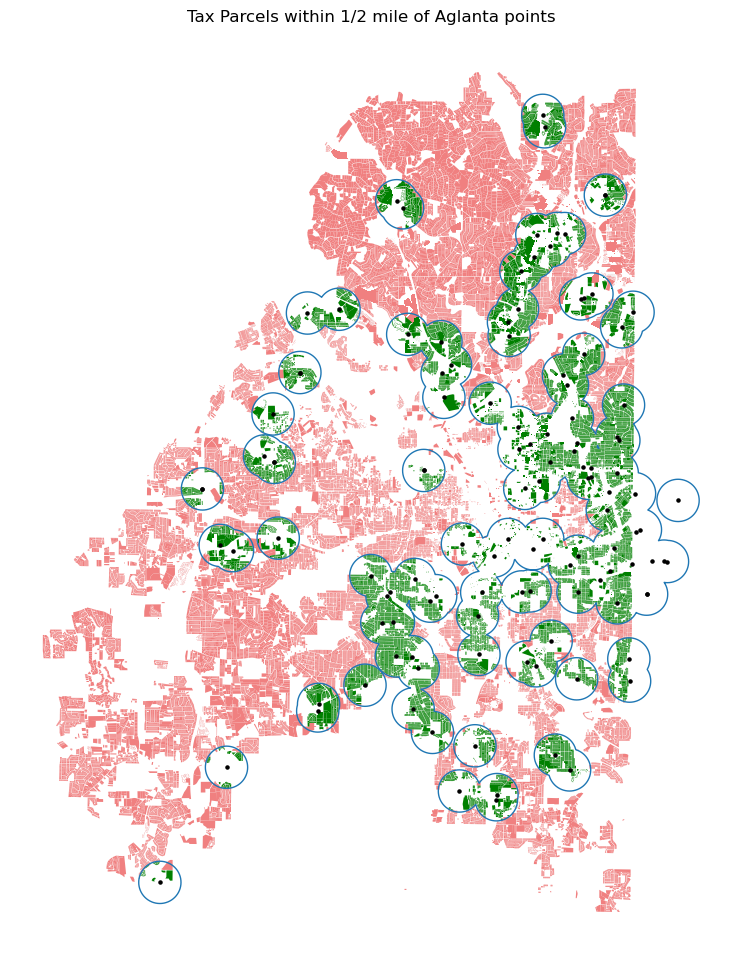

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Ensure same CRS (meters)
gdf_Aglanta = gdf_Aglanta.to_crs(epsg=3857)
gdf_Tax = gdf_Tax.to_crs(epsg=3857)

# 1/2 mile buffer in meters
half_mile_m = 0.5 * 1609.344  # 804.672 m

# Buffer points, dissolve into one geometry (faster + cleaner)
buffer_union = gdf_Aglanta.buffer(half_mile_m).unary_union

# Flag parcels within buffer
gdf_Tax = gdf_Tax.copy()
gdf_Tax["within_half_mile"] = gdf_Tax.geometry.within(buffer_union)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf_Tax.loc[~gdf_Tax["within_half_mile"]].plot(ax=ax, color="lightcoral", linewidth=0)
gdf_Tax.loc[gdf_Tax["within_half_mile"]].plot(ax=ax, color="green", linewidth=0)

# Optional: show points + buffer outline
gdf_Aglanta.plot(ax=ax, color="black", markersize=5)
gpd.GeoSeries([buffer_union], crs=gdf_Tax.crs).boundary.plot(ax=ax, linewidth=1)

ax.set_axis_off()
ax.set_title("Tax Parcels within 1/2 mile of Aglanta points")
plt.show()

/var/folders/4j/d42x79c52dq9lr5g5d4w7vnc0000gn/T/ipykernel_85431/3877699948.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffer_union = gdf_Aglanta.buffer(half_mile_m).unary_union
/opt/anaconda3/envs/qtm151/lib/python3.12/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)
/opt/anaconda3/envs/qtm151/lib/python3.12/site-packages/shapely/predicates.py:1034: RuntimeWarning: invalid value encountered in within
  return lib.within(a, b, **kwargs)


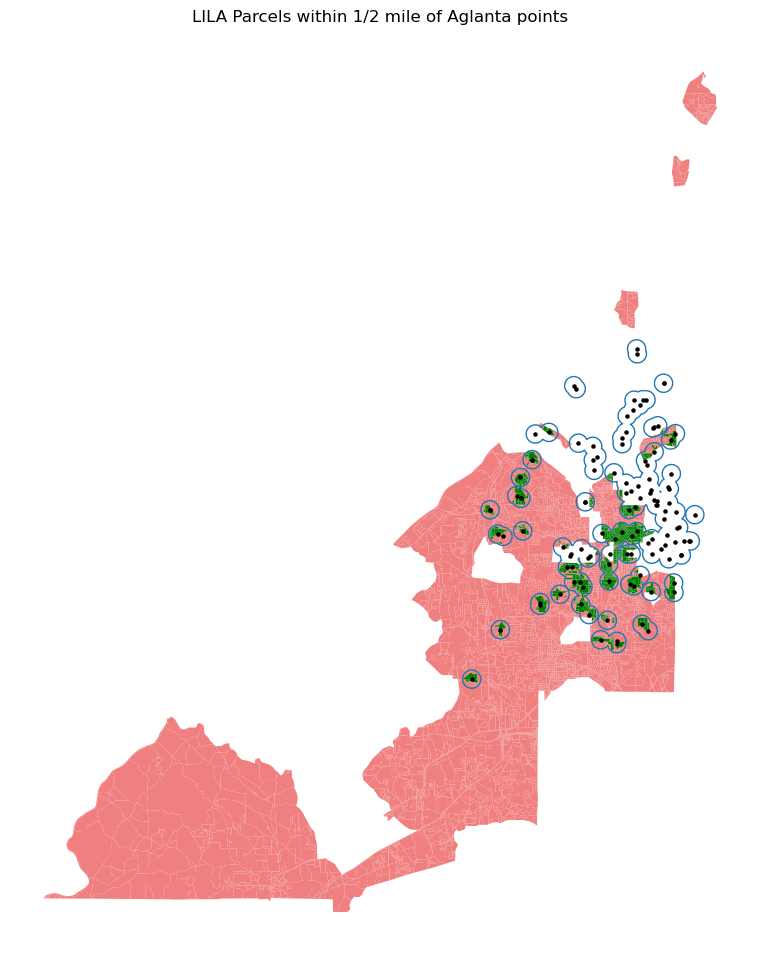

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Ensure same CRS (meters)
gdf_Aglanta = gdf_Aglanta.to_crs(epsg=3857)
gdf_lila = gdf_lila.to_crs(epsg=3857)

# 1/2 mile buffer in meters
half_mile_m = 0.5 * 1609.344  # 804.672 m

# Buffer points, dissolve into one geometry (faster + cleaner)
buffer_union = gdf_Aglanta.buffer(half_mile_m).unary_union

# Flag parcels within buffer
gdf_lila = gdf_lila.copy()
gdf_lila["within_half_mile"] = gdf_lila.geometry.within(buffer_union)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf_lila.loc[~gdf_lila["within_half_mile"]].plot(ax=ax, color="lightcoral", linewidth=0)
gdf_lila.loc[gdf_lila["within_half_mile"]].plot(ax=ax, color="green", linewidth=0)

# Optional: show points + buffer outline
gdf_Aglanta.plot(ax=ax, color="black", markersize=5)
gpd.GeoSeries([buffer_union], crs=gdf_lila.crs).boundary.plot(ax=ax, linewidth=1)

ax.set_axis_off()
ax.set_title("LILA Parcels within 1/2 mile of Aglanta points")
plt.show()

# EDA

In [1]:
gdf_Tax_nonan = gdf_Tax[gdf_Tax["LIVUNITS"].notna()].copy()

NameError: name 'gdf_Tax' is not defined

In [29]:
gdf_Tax_nonan

gdf_Tax_nonan = gdf_Tax[
    gdf_Tax["LIVUNITS"].notna() & (gdf_Tax["LIVUNITS"] > 0)
].copy()

In [30]:
gdf_Tax_nonan

,OBJECTID,LOWPARCELI,PARCELID,BUILDING,UNIT,CVTTXCD,CVTTXDSCRP,CLASSCD,CLASSDSCRP,LIVUNITS,...,COUNCIL,NPU,NEIGHBORHO,ADDRNUM,ADDRSTREET,ADDRSUFFIX,ADDRPOSDIR,SHAPE_Area,SHAPE_Leng,geometry
14131,14132,17 00090001054,17 000900010541,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,3542,KINGSBORO,RD,NE,15410.935673,579.129308,"POLYGON ((-9390244.184 4008838.553, -9390269.9..."
14132,14133,17 00090001075,17 000900010756,#,7,05,None,R3,None,1.0,...,7,B,Ridgedale Park,3533,ROXBORO,RD,NE,1343.911541,157.003657,"POLYGON ((-9390482.762 4008835.19, -9390492.21..."
14133,14134,17 00090001068,17 000900010681,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,987,EULALIA,RD,NE,19103.770553,614.841990,"POLYGON ((-9390354.188 4008920.673, -9390385.8..."
14134,14135,17 00100008015,17 001000080152,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,3627,KINGSBORO,RD,NE,22797.417784,721.541720,"POLYGON ((-9389763.886 4009125.243, -9389833.7..."
14135,14136,17 00090001020,17 000900010202,None,None,05,None,R3,None,1.0,...,7,B,Ridgedale Park,1044,EULALIA,RD,NE,18240.379683,582.265904,"POLYGON ((-9390178.207 4009021.963, -9390178.7..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171001,171002,14 01190005142,14 011900051424,UNIT,305,05T,None,R3,None,1.0,...,4,S,Oakland City,1095,TUCKER,AVE,SW,99.999600,39.999920,"POLYGON ((-9397984.192 3991904.363, -9397984.2..."
171002,171003,14 01190005143,14 011900051432,UNIT,306,05T,None,R3,None,1.0,...,4,S,Oakland City,1095,TUCKER,AVE,SW,99.999600,39.999920,"POLYGON ((-9397979.573 3991900.064, -9397979.5..."
171026,171027,17 0108 LL224,17 0108 LL2242,UNIT,3108,05X,None,R3,None,1.0,...,3,E,Atlantic Station,270,SEVENTEENTH,ST,NW,99.999600,39.999920,"POLYGON ((-9395116.916 4000750.862, -9395116.9..."
171027,171028,17 0108 LL225,17 0108 LL2259,UNIT,3906,05X,None,R3,None,1.0,...,3,E,Atlantic Station,270,SEVENTEENTH,ST,NW,99.999600,39.999920,"POLYGON ((-9395116.916 4000750.862, -9395116.9..."


<Axes: >

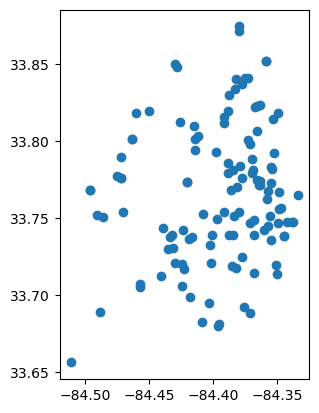

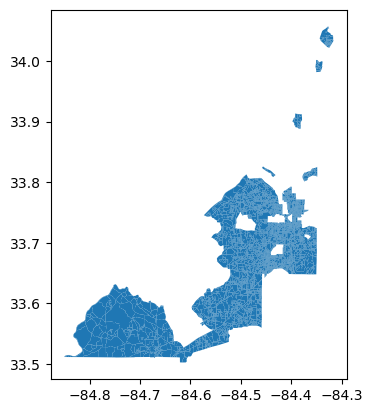

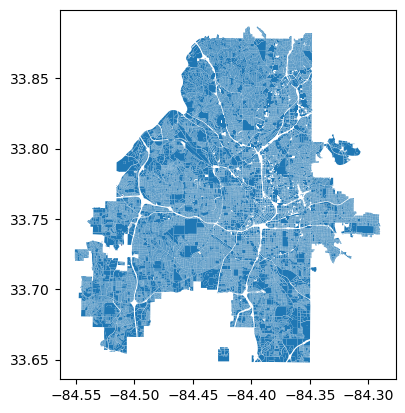

In [41]:
gdf_Aglanta.plot()

gdf_lila.plot()

gdf_Tax.plot()


In [ ]:

print(gdf_Aglanta.crs)      
print(gdf_lila.crs) 
print(gdf_Aglanta.crs) 


EPSG:4326
EPSG:4326
EPSG:4326


In [44]:
gdf_Tax.head()


,OBJECTID,LOWPARCELI,PARCELID,BUILDING,UNIT,CVTTXCD,CVTTXDSCRP,CLASSCD,CLASSDSCRP,LIVUNITS,...,COUNCIL,NPU,NEIGHBORHO,ADDRNUM,ADDRSTREET,ADDRSUFFIX,ADDRPOSDIR,SHAPE_Area,SHAPE_Leng,geometry
0,1,15 203 03 122,15 203 03 122,None,None,61,R3,None,R3,NaN,...,5,O,East Lake,43,OAKRIDGE AVENUE SE,None,SE,9946.353411,405.892255,"POLYGON ((-84.29418 33.75104, -84.29398 33.751..."
1,2,15 205 03 027,15 205 03 027,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,2123,HOSEA L WILLIAMS DRIVE,None,SE,10011.556935,500.472872,"POLYGON ((-84.31811 33.75101, -84.31811 33.750..."
2,3,15 205 02 051,15 205 02 051,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,15,LAKEVIEW DRIVE,None,SE,15959.592623,589.539094,"POLYGON ((-84.3143 33.75071, -84.31429 33.7505..."
3,4,15 205 01 141,15 205 01 141,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,2278,OAKVIEW ROAD,None,NE,7274.229550,392.674789,"POLYGON ((-84.31285 33.75152, -84.31294 33.751..."
4,5,15 205 01 163,15 205 01 163,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,2254,HOSEA L WILLIAMS DRIVE,None,NE,7530.138258,414.175343,"POLYGON ((-84.31359 33.75157, -84.31382 33.751..."


In [45]:
gdf_Tax

,OBJECTID,LOWPARCELI,PARCELID,BUILDING,UNIT,CVTTXCD,CVTTXDSCRP,CLASSCD,CLASSDSCRP,LIVUNITS,...,COUNCIL,NPU,NEIGHBORHO,ADDRNUM,ADDRSTREET,ADDRSUFFIX,ADDRPOSDIR,SHAPE_Area,SHAPE_Leng,geometry
0,1,15 203 03 122,15 203 03 122,None,None,61,R3,None,R3,NaN,...,5,O,East Lake,43,OAKRIDGE AVENUE SE,None,SE,9946.353411,405.892255,"POLYGON ((-84.29418 33.75104, -84.29398 33.751..."
1,2,15 205 03 027,15 205 03 027,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,2123,HOSEA L WILLIAMS DRIVE,None,SE,10011.556935,500.472872,"POLYGON ((-84.31811 33.75101, -84.31811 33.750..."
2,3,15 205 02 051,15 205 02 051,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,15,LAKEVIEW DRIVE,None,SE,15959.592623,589.539094,"POLYGON ((-84.3143 33.75071, -84.31429 33.7505..."
3,4,15 205 01 141,15 205 01 141,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,2278,OAKVIEW ROAD,None,NE,7274.229550,392.674789,"POLYGON ((-84.31285 33.75152, -84.31294 33.751..."
4,5,15 205 01 163,15 205 01 163,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,2254,HOSEA L WILLIAMS DRIVE,None,NE,7530.138258,414.175343,"POLYGON ((-84.31359 33.75157, -84.31382 33.751..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171024,171025,14 01190005157,14 011900051572,UNIT,505,05T,None,R3,None,0.0,...,4,S,Oakland City,1095,TUCKER,AVE,SW,99.999600,39.999920,"POLYGON ((-84.42333 33.72445, -84.42333 33.724..."
171025,171026,14 00190008126,14 001900081265,LOT,185,05TT,None,C3,None,0.0,...,2,N,Inman Park,154,KROG,ST,NE,99.999600,39.999920,"POLYGON ((-84.36395 33.75905, -84.36395 33.759..."
171026,171027,17 0108 LL224,17 0108 LL2242,UNIT,3108,05X,None,R3,None,1.0,...,3,E,Atlantic Station,270,SEVENTEENTH,ST,NW,99.999600,39.999920,"POLYGON ((-84.39777 33.79084, -84.39777 33.790..."
171027,171028,17 0108 LL225,17 0108 LL2259,UNIT,3906,05X,None,R3,None,1.0,...,3,E,Atlantic Station,270,SEVENTEENTH,ST,NW,99.999600,39.999920,"POLYGON ((-84.39777 33.79084, -84.39777 33.790..."


In [43]:
df_License

,license_number,company_name,company_dba,license_classification,issued_date,naics_code,naics_name,predirection,address_line1,address_line2,...,city,state,postal_code,address_concat,address_api,longitude,latitude,disinvested_neighborhood,council_district,npu
0,GBL-0121-00257,H & H Interiors LLC,NaN,Other Services except Public Administration,2025-01-07 13:21:16.143,541410.0,Interior Design Services,NE,2652 Forrest,NaN,...,Atlanta,GA,NaN,2652 Forrest nan WAY Atlanta GA nan,"2652 Forrest Way NE, Atlanta, Georgia, 30305",-84.379893,33.827640,False,7,B
1,GBL-0121-00258,One Lion Studios LLC,NaN,Other Services except Public Administration,2025-02-16 18:39:21.153,541840.0,Media Representatives,NaN,3343 Peachtree Rd NE,NaN,...,Atlanta,GA,30326,3343 Peachtree Rd NE nan nan Atlanta GA 30326,"3343 Peachtree Rd NE, Atlanta, Georgia, 30326",-84.367109,33.846760,False,7,B
2,GBL-0121-00272,Destingkt Designs LLC,NaN,Other Services except Public Administration,2025-03-04 23:04:53.980,541410.0,Interior Design Services,NaN,931,PONCE DE LEON,...,Atlanta,GA,NaN,931 PONCE DE LEON AVE Atlanta GA nan,"931 Ponce de Leon Ave NE, Atlanta, Georgia, 30306",-84.356939,33.773524,False,2,N
3,GBL-0121-00274,Mac Cigars LLC,J's Cigars,Retail Trade,2025-02-25 23:09:11.497,453991.0,Tobacco Stores,NaN,2072,Defoors Ferry,...,Atlanta,GA,30318,2072 Defoors Ferry RD Atlanta GA 30318,"2072 Defoors Ferry Rd NW, Atlanta, Georgia, 30318",-84.426318,33.812071,False,9,D
4,GBL-0121-00283,Essence of She Day Spa Salon,NaN,Other Services except Public Administration,2025-01-09 19:04:30.857,812112.0,Beauty Salons,NaN,144,MORELAND,...,ATLANTA,GA,30307,144 MORELAND AVE ATLANTA GA 30307,"144 Moreland Ave NE, Atlanta, Georgia, 30307",-84.349501,33.756604,False,5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17618,LGB-190652-2020,CAST & CREW PRODUCTION SER LLC,NaN,Manufacturing,2025-03-20 01:03:58.763,512110.0,Motion Picture and Video Production,NaN,1349,W PEACHTREE,...,ATLANTA,GA,30309,1349 W PEACHTREE ST ATLANTA GA 30309,"1349 W Peachtree St NW, Atlanta, Georgia, 30309",-84.387308,33.791687,False,District 6,E
17619,LGB-190653-2020,LISADAESTYLED LLC,NaN,Other Services except Public Administration,2025-03-31 01:02:47.710,561439.0,Other Business Service Centers (including Copy...,NaN,40,PEACHTREE VALLEY,...,ATLANTA,GA,30309,40 PEACHTREE VALLEY RD ATLANTA GA 30309,"40 Peachtree Valley Rd NE, Atlanta, Georgia, 3...",-84.389721,33.811184,False,District 6,E
17620,LGB-190665-2020,"B-T-L PAYROLLS, LLC",NaN,Manufacturing,2025-03-20 01:03:40.333,512110.0,Motion Picture and Video Production,NaN,1349,W PEACHTREE,...,ATLANTA,GA,30309,1349 W PEACHTREE ST ATLANTA GA 30309,"1349 W Peachtree St NW, Atlanta, Georgia, 30309",-84.387308,33.791687,False,District 6,E
17621,LGB-190667-2020,"NEW PAYROLL ASSOCIATES, LLC",NaN,Manufacturing,2025-03-20 01:02:54.400,512110.0,Motion Picture and Video Production,NaN,1349,W PEACHTREE,...,ATLANTA,GA,30309,1349 W PEACHTREE ST ATLANTA GA 30309,"1349 W Peachtree St NW, Atlanta, Georgia, 30309",-84.387308,33.791687,False,District 6,E


CRS before: EPSG:3857


In [40]:
import geopandas as gpd
import folium

# ----------------------
# 1. Read data
# ----------------------
gdf_Aglanta = gpd.read_file("InvestAtlanta_export/Aglanta_FFA_2025_ATL_Only.shp")
gdf_lila = gpd.read_file("InvestAtlanta_export/lila_halfmi_census.shp")
gdf_Tax = gpd.read_file("InvestAtlanta_export/Tax_Parcels_2025.shp")

# ----------------------
# 2. Convert to lat/lon for Folium
# ----------------------
gdf_Aglanta = gdf_Aglanta.to_crs(epsg=4326)
gdf_lila = gdf_lila.to_crs(epsg=4326)
gdf_Tax = gdf_Tax.to_crs(epsg=4326)

# ----------------------
# 3. Compute map center using bounds
# ----------------------
minx, miny, maxx, maxy = gdf_Aglanta.total_bounds
center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="OpenStreetMap"
)

# ----------------------
# 4. Add Satellite option
# ----------------------
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri",
    name="Satellite"
).add_to(m)

# ----------------------
# 5. Add each layer
# ----------------------

# Aglanta FFA (Blue)
folium.GeoJson(
    gdf_Aglanta,
    name="Invest Atlanta FFA",
    style_function=lambda x: {
        "fillColor": "#2b83ba",
        "color": "#2b83ba",
        "weight": 2,
        "fillOpacity": 0.3,
    },
).add_to(m)

# LILA Half-Mile (Green)
folium.GeoJson(
    gdf_lila,
    name="LILA Half-Mile Census",
    style_function=lambda x: {
        "fillColor": "#1a9850",
        "color": "#1a9850",
        "weight": 1.5,
        "fillOpacity": 0.25,
    },
).add_to(m)

# ⚠️ Tax Parcels can be VERY large
# Optional: simplify or sample for speed
gdf_Tax_small = gdf_Tax.simplify(0.00005)  # reduce geometry complexity

folium.GeoJson(
    gdf_Tax_small,
    name="Tax Parcels",
    style_function=lambda x: {
        "fillColor": "#d73027",
        "color": "#d73027",
        "weight": 0.5,
        "fillOpacity": 0.1,
    },
).add_to(m)

# ----------------------
# 6. Layer control
# ----------------------
folium.LayerControl(collapsed=False).add_to(m)

# ----------------------
# 7. Save map
# ----------------------
m.save("Invest_Atlanta_MultiLayer_Map.html")


/opt/anaconda3/envs/qtm151/lib/python3.12/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)


# Tax Parcel

In [8]:
list(enumerate(gdf_Tax.columns))

[(0, 'OBJECTID'),
 (1, 'LOWPARCELI'),
 (2, 'PARCELID'),
 (3, 'BUILDING'),
 (4, 'UNIT'),
 (5, 'CVTTXCD'),
 (6, 'CVTTXDSCRP'),
 (7, 'CLASSCD'),
 (8, 'CLASSDSCRP'),
 (9, 'LIVUNITS'),
 (10, 'SITEADDRES'),
 (11, 'SITECITY'),
 (12, 'SITESTATE'),
 (13, 'SITEZIP'),
 (14, 'PRPRTYDSCR'),
 (15, 'CNVYNAME'),
 (16, 'OWNERNME1'),
 (17, 'OWNERNME2'),
 (18, 'PSTLADDRES'),
 (19, 'PSTLADDR_1'),
 (20, 'PSTLCITY'),
 (21, 'PSTLSTATE'),
 (22, 'PSTLZIP5'),
 (23, 'PSTLZIP4'),
 (24, 'LNDVALUE'),
 (25, 'TOT_APPR'),
 (26, 'IMPR_APPR'),
 (27, 'LANDASSESS'),
 (28, 'IMPRASSESS'),
 (29, 'LANDAPPR'),
 (30, 'PRVASSDVAL'),
 (31, 'CNTASSDVAL'),
 (32, 'LASTUPDATE'),
 (33, 'CREATED_US'),
 (34, 'CREATED_DA'),
 (35, 'LAST_EDITE'),
 (36, 'LAST_EDI_1'),
 (37, 'GLOBALID'),
 (38, 'ORDNAME'),
 (39, 'ORDLINK'),
 (40, 'ORDSTATUS'),
 (41, 'TAXYEAR'),
 (42, 'ZONING1'),
 (43, 'ZONING2'),
 (44, 'COUNCIL'),
 (45, 'NPU'),
 (46, 'NEIGHBORHO'),
 (47, 'ADDRNUM'),
 (48, 'ADDRSTREET'),
 (49, 'ADDRSUFFIX'),
 (50, 'ADDRPOSDIR'),
 (51, 'SHAPE_A

In [7]:
cols = [
    "PARCELID",
    "CLASSDSCRP",
    "LIVUNITS",
    "LNDVALUE",
    "SITEZIP",
    "SITECITY",
    "PSTLCITY",
    "SHAPE_Area",
    "geometry"
]

gdf_Tax_model = gdf_Tax[cols]

gdf_Tax_model

,PARCELID,CLASSDSCRP,LIVUNITS,LNDVALUE,SITEZIP,SITECITY,PSTLCITY,SHAPE_Area,geometry
0,15 203 03 122,R3,NaN,0.0,30317,ATLANTA,ATLANTA,9946.353411,"POLYGON ((-9383584.987 3995422.194, -9383562.8..."
1,15 205 03 027,R3,NaN,0.0,30317,ATLANTA,ATLANTA,10011.556935,"POLYGON ((-9386249.463 3995417.456, -9386249.3..."
2,15 205 02 051,R3,NaN,0.0,30317,ATLANTA,ATLANTA,15959.592623,"POLYGON ((-9385825.492 3995377.259, -9385823.3..."
3,15 205 01 141,R3,NaN,0.0,30317,ATLANTA,ATLANTA,7274.229550,"POLYGON ((-9385663.364 3995486.35, -9385673.38..."
4,15 205 01 163,R3,NaN,0.0,30317,ATLANTA,ATLANTA,7530.138258,"POLYGON ((-9385745.932 3995492.23, -9385771.04..."
...,...,...,...,...,...,...,...,...,...
171024,14 011900051572,None,0.0,NaN,30310,ATLANTA,None,99.999600,"POLYGON ((-9397962.025 3991862.6, -9397962.034..."
171025,14 001900081265,None,0.0,NaN,30307,ATLANTA,None,99.999600,"POLYGON ((-9391351.47 3996494.667, -9391351.47..."
171026,17 0108 LL2242,None,1.0,NaN,30363,ATLANTA,None,99.999600,"POLYGON ((-9395116.916 4000750.862, -9395116.9..."
171027,17 0108 LL2259,None,1.0,NaN,30363,ATLANTA,None,99.999600,"POLYGON ((-9395116.916 4000750.862, -9395116.9..."


In [11]:
gdf_Tax_model = gdf_Tax.to_crs(epsg=3857)

gdf_Tax_model

,OBJECTID,LOWPARCELI,PARCELID,BUILDING,UNIT,CVTTXCD,CVTTXDSCRP,CLASSCD,CLASSDSCRP,LIVUNITS,...,COUNCIL,NPU,NEIGHBORHO,ADDRNUM,ADDRSTREET,ADDRSUFFIX,ADDRPOSDIR,SHAPE_Area,SHAPE_Leng,geometry
0,1,15 203 03 122,15 203 03 122,None,None,61,R3,None,R3,NaN,...,5,O,East Lake,43,OAKRIDGE AVENUE SE,None,SE,9946.353411,405.892255,"POLYGON ((-9383584.987 3995422.194, -9383562.8..."
1,2,15 205 03 027,15 205 03 027,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,2123,HOSEA L WILLIAMS DRIVE,None,SE,10011.556935,500.472872,"POLYGON ((-9386249.463 3995417.456, -9386249.3..."
2,3,15 205 02 051,15 205 02 051,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,15,LAKEVIEW DRIVE,None,SE,15959.592623,589.539094,"POLYGON ((-9385825.492 3995377.259, -9385823.3..."
3,4,15 205 01 141,15 205 01 141,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,2278,OAKVIEW ROAD,None,NE,7274.229550,392.674789,"POLYGON ((-9385663.364 3995486.35, -9385673.38..."
4,5,15 205 01 163,15 205 01 163,None,None,61,R3,None,R3,NaN,...,5,O,Kirkwood,2254,HOSEA L WILLIAMS DRIVE,None,NE,7530.138258,414.175343,"POLYGON ((-9385745.932 3995492.23, -9385771.04..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171024,171025,14 01190005157,14 011900051572,UNIT,505,05T,None,R3,None,0.0,...,4,S,Oakland City,1095,TUCKER,AVE,SW,99.999600,39.999920,"POLYGON ((-9397962.025 3991862.6, -9397962.034..."
171025,171026,14 00190008126,14 001900081265,LOT,185,05TT,None,C3,None,0.0,...,2,N,Inman Park,154,KROG,ST,NE,99.999600,39.999920,"POLYGON ((-9391351.47 3996494.667, -9391351.47..."
171026,171027,17 0108 LL224,17 0108 LL2242,UNIT,3108,05X,None,R3,None,1.0,...,3,E,Atlantic Station,270,SEVENTEENTH,ST,NW,99.999600,39.999920,"POLYGON ((-9395116.916 4000750.862, -9395116.9..."
171027,171028,17 0108 LL225,17 0108 LL2259,UNIT,3906,05X,None,R3,None,1.0,...,3,E,Atlantic Station,270,SEVENTEENTH,ST,NW,99.999600,39.999920,"POLYGON ((-9395116.916 4000750.862, -9395116.9..."


In [ ]:
import geopandas as gpd
import numpy as np

# 1) Select columns
cols = [
    "PARCELID",
    "CLASSDSCRP",
    "LIVUNITS",
    "LNDVALUE",
    "SITEZIP",
    "SITECITY",
    "PSTLCITY",
    "SHAPE_Area",
    "geometry"
]

gdf_Tax_model = gdf_Tax[cols].copy()


gdf_Tax_model = gdf_Tax_model.to_crs(epsg=3857)


gdf_Tax_points = gdf_Tax_model.copy()
gdf_Tax_points["geometry"] = gdf_Tax_points.geometry.representative_point()


gdf_Tax_points["x"] = gdf_Tax_points.geometry.x
gdf_Tax_points["y"] = gdf_Tax_points.geometry.y


for c in ["LIVUNITS", "LNDVALUE", "SHAPE_Area"]:
    gdf_Tax_points[c] = gdf_Tax_points[c].replace({None: np.nan})
    gdf_Tax_points[c] = gdf_Tax_points[c].astype("float64", errors="ignore") if hasattr(pd := __import__("pandas"), "to_numeric") else gdf_Tax_points[c]

import pandas as pd
for c in ["LIVUNITS", "LNDVALUE", "SHAPE_Area"]:
    gdf_Tax_points[c] = pd.to_numeric(gdf_Tax_points[c], errors="coerce")


gdf_Tax_points["is_residential"] = gdf_Tax_points["CLASSDSCRP"].isin(["R1", "R2", "R3"])


gdf_Tax_points["absentee_owner"] = (
    gdf_Tax_points["SITECITY"].fillna("").str.upper().str.strip()
    != gdf_Tax_points["PSTLCITY"].fillna("").str.upper().str.strip()
)


gdf_Tax_points["units_per_m2"] = np.where(
    (gdf_Tax_points["SHAPE_Area"] > 0) & (~gdf_Tax_points["LIVUNITS"].isna()),
    gdf_Tax_points["LIVUNITS"] / gdf_Tax_points["SHAPE_Area"],
    np.nan
)


gdf_Tax_points["landvalue_per_m2"] = np.where(
    (gdf_Tax_points["SHAPE_Area"] > 0) & (~gdf_Tax_points["LNDVALUE"].isna()),
    gdf_Tax_points["LNDVALUE"] / gdf_Tax_points["SHAPE_Area"],
    np.nan
)


gdf_Tax_points = gdf_Tax_points[
    cols[:-1] + ["x", "y", "is_residential", "absentee_owner", "units_per_m2", "landvalue_per_m2", "geometry"]
].copy()

gdf_Tax_points.head()

,PARCELID,CLASSDSCRP,LIVUNITS,LNDVALUE,SITEZIP,SITECITY,PSTLCITY,SHAPE_Area,x,y,is_residential,absentee_owner,units_per_m2,landvalue_per_m2,geometry
0,15 203 03 122,R3,NaN,0.0,30317,ATLANTA,ATLANTA,9946.353411,-9.383586e+06,3.995406e+06,True,False,NaN,0.0,POINT (-9383585.868 3995405.985)
1,15 205 03 027,R3,NaN,0.0,30317,ATLANTA,ATLANTA,10011.556935,-9.386259e+06,3.995381e+06,True,False,NaN,0.0,POINT (-9386258.548 3995380.718)
2,15 205 02 051,R3,NaN,0.0,30317,ATLANTA,ATLANTA,15959.592623,-9.385865e+06,3.995368e+06,True,False,NaN,0.0,POINT (-9385864.696 3995367.752)
3,15 205 01 141,R3,NaN,0.0,30317,ATLANTA,ATLANTA,7274.229550,-9.385703e+06,3.995495e+06,True,False,NaN,0.0,POINT (-9385703.453 3995494.751)
4,15 205 01 163,R3,NaN,0.0,30317,ATLANTA,ATLANTA,7530.138258,-9.385768e+06,3.995468e+06,True,False,NaN,0.0,POINT (-9385768.386 3995467.741)


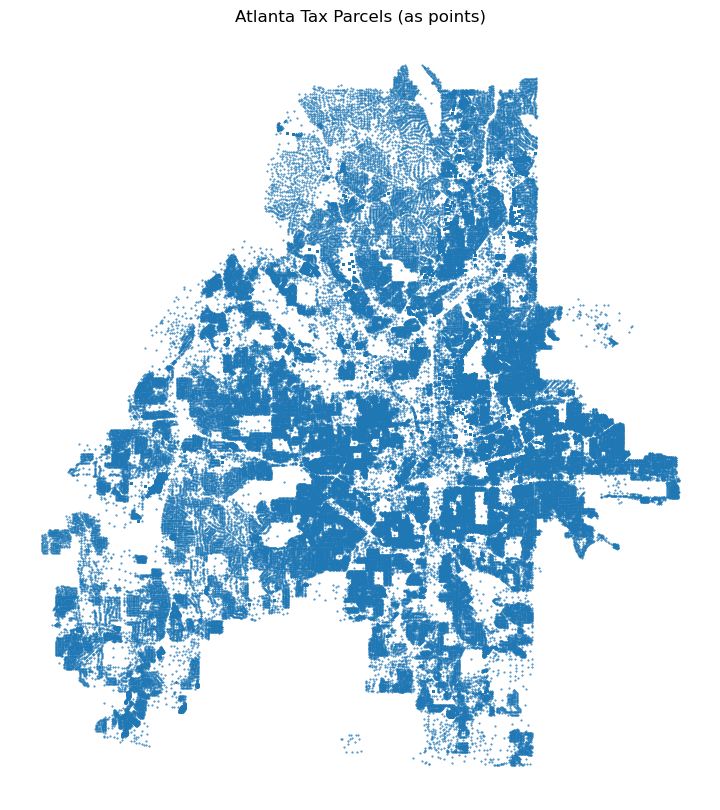

In [14]:
import matplotlib.pyplot as plt

# If your points are in EPSG:3857, plot directly (units meters, fine for a quick map)
ax = gdf_Tax_points.plot(figsize=(10, 10), markersize=0.2)
ax.set_title("Atlanta Tax Parcels (as points)")
ax.set_axis_off()
plt.show()

/opt/anaconda3/envs/qtm151/lib/python3.12/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)
/var/folders/4j/d42x79c52dq9lr5g5d4w7vnc0000gn/T/ipykernel_21633/3913563826.py:99: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left")


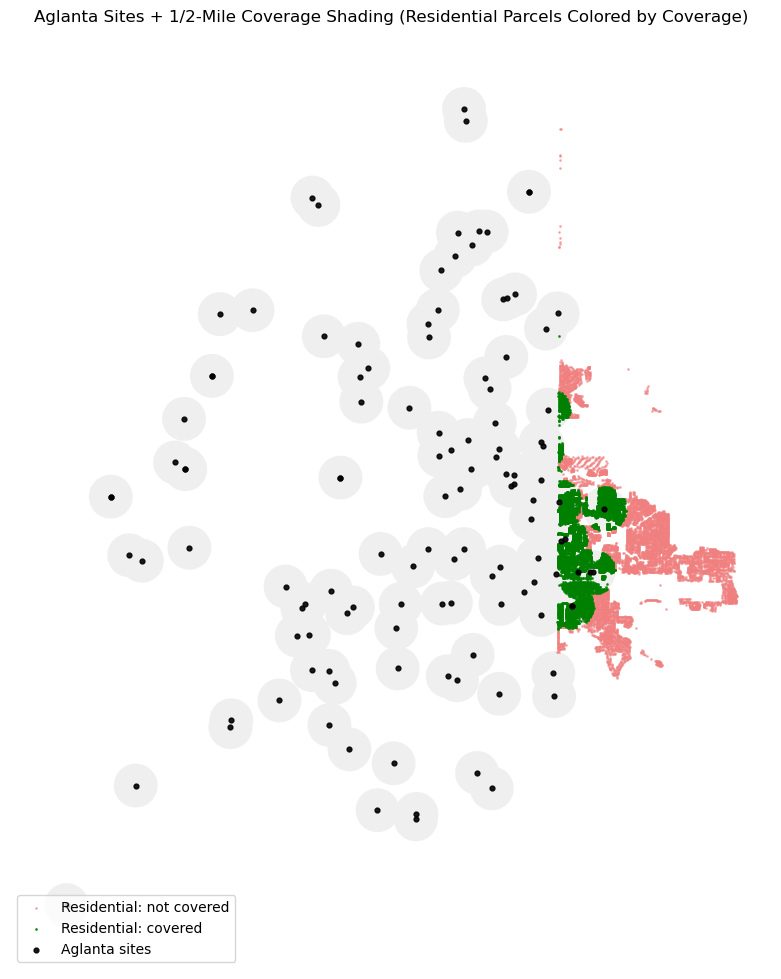

In [25]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.ops import unary_union

# =========================
# YOUR EXISTING PIPELINE
# =========================
cols = [
    "PARCELID","CLASSDSCRP","LIVUNITS","LNDVALUE","SITEZIP",
    "SITECITY","PSTLCITY","SHAPE_Area","geometry"
]

gdf_Tax_model = gdf_Tax[cols].copy()
gdf_Tax_model = gdf_Tax_model.to_crs(epsg=3857)

gdf_Tax_points = gdf_Tax_model.copy()
gdf_Tax_points["geometry"] = gdf_Tax_points.geometry.representative_point()

gdf_Tax_points["x"] = gdf_Tax_points.geometry.x
gdf_Tax_points["y"] = gdf_Tax_points.geometry.y

for c in ["LIVUNITS", "LNDVALUE", "SHAPE_Area"]:
    gdf_Tax_points[c] = pd.to_numeric(gdf_Tax_points[c], errors="coerce")

gdf_Tax_points["is_residential"] = gdf_Tax_points["CLASSDSCRP"].isin(["R1", "R2", "R3"])

gdf_Tax_points["absentee_owner"] = (
    gdf_Tax_points["SITECITY"].fillna("").str.upper().str.strip()
    != gdf_Tax_points["PSTLCITY"].fillna("").str.upper().str.strip()
)

gdf_Tax_points["units_per_m2"] = np.where(
    (gdf_Tax_points["SHAPE_Area"] > 0) & (~gdf_Tax_points["LIVUNITS"].isna()),
    gdf_Tax_points["LIVUNITS"] / gdf_Tax_points["SHAPE_Area"],
    np.nan
)

gdf_Tax_points["landvalue_per_m2"] = np.where(
    (gdf_Tax_points["SHAPE_Area"] > 0) & (~gdf_Tax_points["LNDVALUE"].isna()),
    gdf_Tax_points["LNDVALUE"] / gdf_Tax_points["SHAPE_Area"],
    np.nan
)

gdf_Tax_points = gdf_Tax_points[
    cols[:-1] + ["x", "y", "is_residential", "absentee_owner", "units_per_m2", "landvalue_per_m2", "geometry"]
].copy()

# =========================
# AGLANTA + 1/2-MILE SHADING
# =========================

# Make sure Aglanta is in the same CRS (meters)
gdf_Aglanta_3857 = gdf_Aglanta.to_crs(epsg=3857)

# 0.5 mile in meters
half_mile_m = 1609.344 / 2  # 804.672

# Create a single "coverage" polygon by buffering all Aglanta points and unioning
coverage_geom = unary_union(gdf_Aglanta_3857.geometry.buffer(half_mile_m))

coverage_gdf = gpd.GeoDataFrame({"name": ["Aglanta 1/2 mile coverage"]},
                                geometry=[coverage_geom],
                                crs="EPSG:3857")

# Residential points only (as requested)
gdf_res = gdf_Tax_points[gdf_Tax_points["is_residential"]].copy()

# Optional: classify each residential parcel as covered/not covered (by buffer)
gdf_res["within_half_mile"] = gdf_res.within(coverage_geom)

# =========================
# PLOT
#   - shade: 1/2 mile coverage area
#   - points: residential parcels (green covered / light red not)
#   - points: Aglanta sites (black)
# =========================
fig, ax = plt.subplots(figsize=(12, 12))

# Shade coverage area
coverage_gdf.plot(ax=ax, color="lightgrey", alpha=0.35, edgecolor="none", label="1/2 mile coverage area")

# Residential parcels: not covered (light red)
gdf_res.loc[~gdf_res["within_half_mile"]].plot(
    ax=ax, color="lightcoral", markersize=1.0, alpha=0.55, label="Residential: not covered"
)

# Residential parcels: covered (green)
gdf_res.loc[gdf_res["within_half_mile"]].plot(
    ax=ax, color="green", markersize=1.0, alpha=0.8, label="Residential: covered"
)

# Aglanta sites on top
gdf_Aglanta_3857.plot(ax=ax, color="black", markersize=12, alpha=0.9, label="Aglanta sites")

ax.set_title("Aglanta Sites + 1/2-Mile Coverage Shading (Residential Parcels Colored by Coverage)")
ax.set_axis_off()
ax.legend(loc="lower left")
plt.show()